# I - Khai Báo Thư Viên

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import tqdm 
import seaborn as sns 
from IPython.display import display

# II - Đọc Dữ Liệu

In [2]:
data = pd.read_csv("./data/data-commerce-clean.csv") 

#### Tổng quan tỷ lệ chuyển đổi trên toàn bộ dataset:

In [3]:
data['event_time'] = pd.to_datetime(data['event_time'])

print("Tổng quan về dataset : ")
print(data['event_type'].value_counts())
print("\nSố sản phẩm duy nhất:", data['product_id'].nunique())
print("Số user duy nhất:", data['user_id'].nunique())
print("Số session duy nhất:", data['user_session'].nunique())

print("\nFunnel tổng thể : ")
views = len(data[data['event_type'] == 'view'])
carts = len(data[data['event_type'] == 'cart'])
purchases = len(data[data['event_type'] == 'purchase'])

print(f"Tổng views      : {views:,}")
print(f"Tổng cart       : {carts:,}")
print(f"Tổng purchases  : {purchases:,}")
print(f"View → Cart     : {carts/views*100:6.2f}%")
print(f"Cart → Purchase : {purchases/carts*100:6.2f}%")
print(f"View → Purchase : {purchases/views*100:6.4f}%")

Tổng quan về dataset : 
event_type
view        25201706
cart          809407
purchase      549507
Name: count, dtype: int64

Số sản phẩm duy nhất: 60371
Số user duy nhất: 2323036
Số session duy nhất: 6419693

Funnel tổng thể : 
Tổng views      : 25,201,706
Tổng cart       : 809,407
Tổng purchases  : 549,507
View → Cart     :   3.21%
Cart → Purchase :  67.89%
View → Purchase : 2.1804%


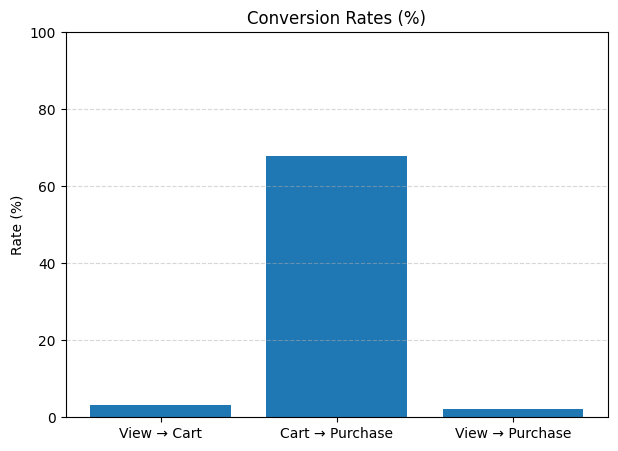

In [4]:
conv_labels = ["View → Cart", "Cart → Purchase", "View → Purchase"]
conv_values = [carts / views * 100, purchases / carts * 100, purchases / views * 100]

plt.figure(figsize=(7, 5))
plt.bar(conv_labels, conv_values)
plt.title("Conversion Rates (%)")
plt.ylabel("Rate (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [5]:
categories = data["category_code"].unique()

category_result = []

for cat in categories:
    df_cat = data[data["category_code"] == cat]
    ET_cat = df_cat["event_type"].value_counts()

    view = ET_cat.get("view", 0)
    cart = ET_cat.get("cart", 0)
    purchase = ET_cat.get("purchase", 0)

    view_cart = (cart / view * 100) if view > 0 else 0
    cart_purchase = (purchase / cart * 100) if cart > 0 else 0
    view_purchase = (purchase / view * 100) if view > 0 else 0

    category_result.append(
        [
            cat,
            view,
            cart,
            purchase,
            round(view_cart, 2),
            round(cart_purchase, 2),
            round(view_purchase, 2),
        ]
    )

category_df = pd.DataFrame(
    category_result,
    columns=[
        "category",
        "view",
        "cart",
        "purchase",
        "view→cart(%)",
        "cart→purchase(%)",
        "view→purchase(%)",
    ],
)

display(category_df)

,category,view,cart,purchase,view→cart(%),cart→purchase(%),view→purchase(%)
0,appliances.environment.water_heater,132790,3911,2694,2.95,68.88,2.03
1,computers.notebook,1100127,15595,15547,1.42,99.69,1.41
2,electronics.smartphone,10598372,549373,337575,5.18,61.45,3.19
3,computers.desktop,396909,3070,3091,0.77,100.68,0.78
4,apparel.shoes.keds,354205,0,2336,0.00,0.00,0.66
...,...,...,...,...,...,...,...
121,apparel.belt,366,0,4,0.00,0.00,1.09
122,apparel.jeans,1935,0,3,0.00,0.00,0.16
123,construction.tools.soldering,201,0,0,0.00,0.00,0.00
124,apparel.jumper,1715,0,2,0.00,0.00,0.12


In [6]:
print("\nPhân tích theo sản phẩm : ")

prod = (
    data.groupby(["product_id", "category_code", "event_type"])
    .size()
    .unstack(fill_value=0)
)

for col in ["view", "cart", "purchase"]:
    if col not in prod.columns:
        prod[col] = 0

prod["view_to_cart_rate"] = prod["cart"] / prod["view"]
prod["cart_to_purchase_rate"] = np.where(
    prod["cart"] > 0, prod["purchase"] / prod["cart"], 0
)
prod["view_to_purchase_rate"] = prod["purchase"] / prod["view"]

prod_filtered = prod[prod["view"] >= 50].copy()

print(f"\nSố sản phẩm có ≥ 50 view: {len(prod_filtered):,}")
print(
    f"View → Purchase Rate : {prod_filtered['view_to_purchase_rate'].mean()*100:.3f}%"
)
print(
    f"View → Purchase Rate : {prod_filtered['view_to_purchase_rate'].median()*100:.3f}%"
)

print("\nTop 10 sản phẩm tỷ lệ chuyển đổi cao nhất ( ≥50 view ) :")

top_conv = prod_filtered.nlargest(10, "view_to_purchase_rate")[
    ["view", "cart", "purchase", "view_to_purchase_rate"]
]

top_conv = top_conv.reset_index()
top_conv["view_to_purchase_rate"] = (top_conv["view_to_purchase_rate"] * 100).round(
    3
).astype(str) + "%"

display(top_conv)

print("\nTop 10 sản phẩm có số lượt xem cao nhưng tỷ lệ chuyển đổi thấp :")
low_conv = prod_filtered[
    prod_filtered["view_to_purchase_rate"]
    < prod_filtered["view_to_purchase_rate"].quantile(0.2)
].nlargest(10, "view")[["view", "purchase", "view_to_purchase_rate"]]
low_conv = low_conv.reset_index()
low_conv["view_to_purchase_rate"] = (low_conv["view_to_purchase_rate"] * 100).round(
    3
).astype(str) + "%"

print(low_conv)


Phân tích theo sản phẩm : 

Số sản phẩm có ≥ 50 view: 25,375
View → Purchase Rate : 0.784%
View → Purchase Rate : 0.521%

Top 10 sản phẩm tỷ lệ chuyển đổi cao nhất ( ≥50 view ) :


event_type,product_id,category_code,view,cart,purchase,view_to_purchase_rate
0,4201530,appliances.environment.air_conditioner,107,0,15,14.019%
1,4201541,appliances.environment.air_conditioner,636,0,83,13.05%
2,1304995,computers.notebook,56,3,7,12.5%
3,4201539,appliances.environment.air_conditioner,51,0,6,11.765%
4,16200324,kids.fmcg.diapers,71,0,8,11.268%
5,18900368,electronics.camera.photo,349,0,38,10.888%
6,9100580,computers.peripherals.mouse,57,2,6,10.526%
7,6200264,appliances.environment.air_heater,58,0,6,10.345%
8,16200286,kids.fmcg.diapers,256,0,25,9.766%
9,6500548,computers.components.motherboard,304,0,29,9.539%



Top 10 sản phẩm có số lượt xem cao nhưng tỷ lệ chuyển đổi thấp :
Empty DataFrame
Columns: [product_id, category_code, view, purchase, view_to_purchase_rate]
Index: []


In [8]:
corr = prod_filtered["view"].corr(prod_filtered["purchase"])
print(f"\nCorrelation View ↔ Purchase: {corr:.3f}")

if "price" in data.columns:
    print("\nTỷ lệ chuyển đổi theo khoảng giá : ")
if "brand" in data.columns:
    print("\nTop 10 thương hiệu có tỷ lệ chuyển đổi cao nhất : ")
    
    brand_data = data[data["event_type"].isin(["view", "purchase"])].copy()
    
    brand_stats = (
        brand_data.groupby(["brand", "category_code", "event_type"])
        .size()
        .unstack(fill_value=0)
    )
    
    brand_stats["conv_rate"] = brand_stats["purchase"] / brand_stats["view"]
    
    top_brands = brand_stats.nlargest(10, "conv_rate")[
        ["view", "purchase", "conv_rate"]
    ].copy()
    
    top_brands = top_brands.reset_index()
    top_brands["conv_rate"] = (
        (top_brands["conv_rate"] * 100).round(2).astype(str) + "%"
    )
    
    display(top_brands)



Correlation View ↔ Purchase: 0.939

Tỷ lệ chuyển đổi theo khoảng giá : 

Top 10 thương hiệu có tỷ lệ chuyển đổi cao nhất : 


event_type,brand,category_code,view,purchase,conv_rate
0,casela,construction.components.faucet,28,4,14.29%
1,bouncin,kids.dolls,18,2,11.11%
2,neptun,construction.components.faucet,27,3,11.11%
3,artel,appliances.environment.air_conditioner,953,104,10.91%
4,doona,kids.carriage,10,1,10.0%
5,jika,furniture.bathroom.bath,32,3,9.38%
6,crusader,electronics.audio.acoustic,11,1,9.09%
7,faans,furniture.bathroom.toilet,22,2,9.09%
8,oribel,furniture.kitchen.chair,11,1,9.09%
9,saturn,appliances.kitchen.microwave,12,1,8.33%


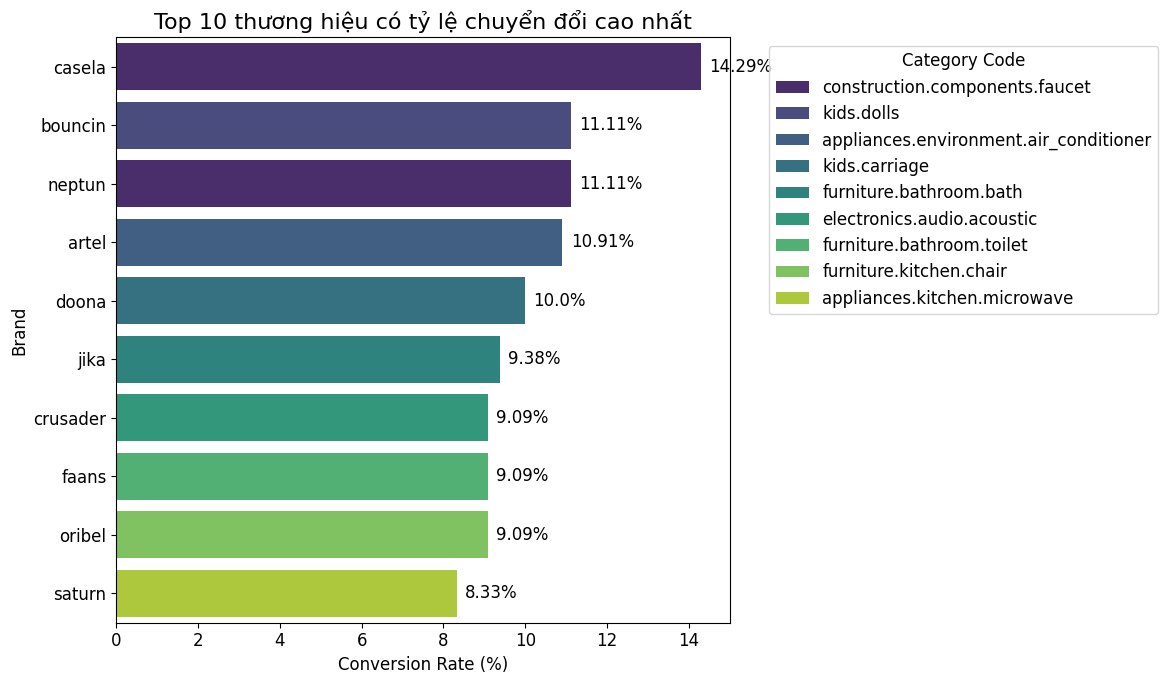

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

brand_plot = top_brands.copy()
brand_plot["conv_rate_num"] = brand_plot["conv_rate"].str.replace("%", "").astype(float)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=brand_plot,
    x="conv_rate_num",
    y="brand",
    hue="category_code", 
    palette="viridis",
)

plt.title("Top 10 thương hiệu có tỷ lệ chuyển đổi cao nhất", fontsize=16)
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Brand")
plt.legend(title="Category Code", bbox_to_anchor=(1.05, 1), loc="upper left")

for index, row in brand_plot.iterrows():
    plt.text(row["conv_rate_num"] + 0.2, index, f"{row['conv_rate']}", va="center")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

use_cols = [
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session",
]

df = pd.read_csv("./data/data-commerce-clean.csv", usecols=use_cols, parse_dates=["event_time"])
print(df.shape)

(26560620, 9)


Thống kê số lần view trước khi mua:
count    548517.000000
mean          5.312045
std           9.128465
min           1.000000
25%           1.000000
50%           3.000000
75%           6.000000
max         310.000000
Name: view_count_before_purchase, dtype: float64


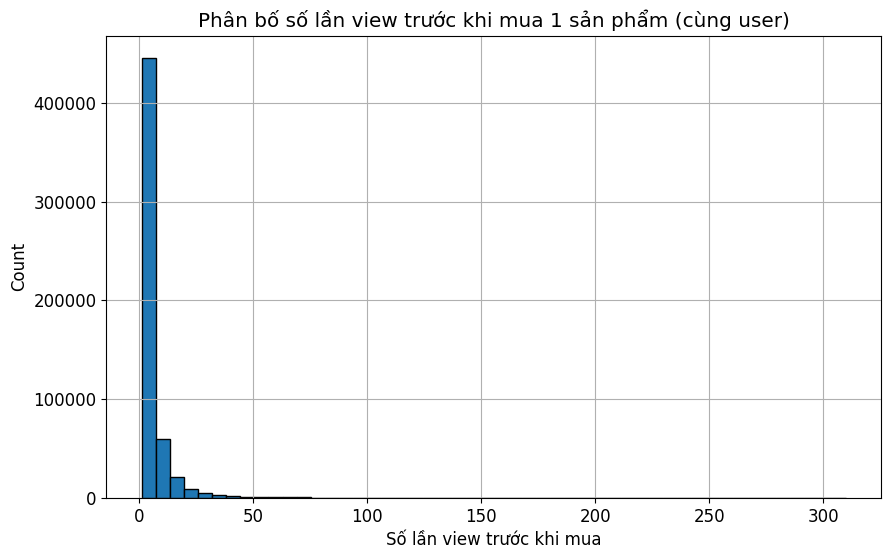

Tỷ lệ người mua hàng nếu đã xem ≥ n lần:
≥1 lần: 32.12%
≥2 lần: 48.10%
≥3 lần: 59.46%
≥5 lần: 73.20%
≥10 lần: 88.19%


In [ ]:
view_before_purchase = []
purchase_df = df[df["event_type"] == "purchase"][
    ["user_id", "product_id", "event_time"]
]
view_df = df[df["event_type"] == "view"][["user_id", "product_id", "event_time"]]

merged = purchase_df.merge(
    view_df, on=["user_id", "product_id"], suffixes=("_purchase", "_view")
)
merged = merged[merged["event_time_view"] < merged["event_time_purchase"]]

views_per_purchase = (
    merged.groupby(["user_id", "product_id", "event_time_purchase"])
    .size()
    .reset_index(name="view_count_before_purchase")
)

print("Thống kê số lần view trước khi mua:")
print(views_per_purchase["view_count_before_purchase"].describe())

plt.figure(figsize=(10, 6))
views_per_purchase["view_count_before_purchase"].hist(bins=50, edgecolor="black")
plt.title("Phân bố số lần view trước khi mua 1 sản phẩm (cùng user)")
plt.xlabel("Số lần view trước khi mua")
plt.ylabel("Count")
plt.show()

rate_by_views = (
    views_per_purchase.groupby("view_count_before_purchase").size().cumsum()
    / len(views_per_purchase)
    * 100
)

print("Tỷ lệ người mua hàng nếu đã xem ≥ n lần:")
for n in [1, 2, 3, 5, 10]:
    try:
        print(f"≥{n} lần: {rate_by_views[n]:.2f}%")
    except:
        pass

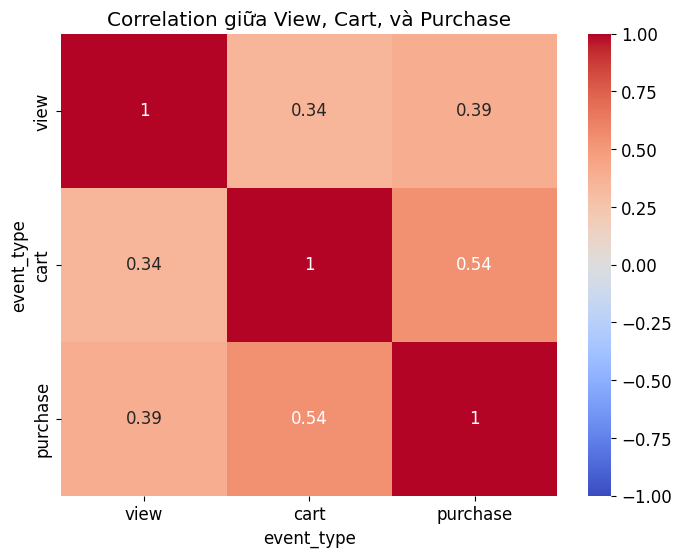

In [ ]:
import seaborn as sns

corr_df = data.pivot_table(
    index=["user_id", "product_id"], columns="event_type", aggfunc="size", fill_value=0
)

corr_df = corr_df[["view", "cart", "purchase"]]
corr = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation giữa View, Cart, và Purchase")
plt.show()